# OmniMedVQA-V2 EDA

## Environment setup

Run the optional installation command in Colab only if the required packages are missing.

In [1]:
# Directory
from pathlib import Path

def find_project_root(start=Path.cwd(), project_name="attack-on-medvqa"):
    start = Path(start).resolve()

    for path in [start, *start.parents]:
        if path.name == project_name:
            return path

    raise FileNotFoundError(f"Could not find project root named {project_name}")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "OmniMedVQA"
DATA_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = str(DATA_DIR)

print("Project root:", PROJECT_ROOT)
print("Dataset cache:", CACHE_DIR)

Project root: /home/euro/code/sheffield/dissertation/attack-on-medvqa
Dataset cache: /home/euro/code/sheffield/dissertation/attack-on-medvqa/data/OmniMedVQA


In [2]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from pathlib import Path
import random

# sns.set_theme(style="whitegrid")
# plt.rcParams["figure.figsize"] = (10, 6)
# plt.rcParams["axes.titlesize"] = 14
# plt.rcParams["axes.labelsize"] = 12
# pd.set_option("display.max_columns", 120)
# pd.set_option("display.max_colwidth", 160)

In [3]:
OMNIMEDVQA_V2_DATASET = "mtybilly/OmniMedVQA-V2"

SUBSETS = [
    "mod-ct",
    "mod-derm",
    "mod-fundus",
    "mod-micro",
    "mod-mri",
    "mod-oct",
    "mod-us",
    "mod-xray",
    
    "qt-ai",
    "qt-dd",
    "qt-lg",
    "qt-mr",
    "qt-oba",
]


## Load OmniMedVQA-V2 test data


In [4]:
test_datasets = []

for subset in SUBSETS:
    print(f"Loading subset: {subset}")

    test_files = f"hf://datasets/{OMNIMEDVQA_V2_DATASET}/{subset}/test-*.parquet"

    ds = load_dataset(
        "parquet",
        data_files={"test": test_files},
        split="test",
        cache_dir=CACHE_DIR,
    )

    ds = ds.add_column("subset", [subset] * len(ds))

    category = "modality" if subset.startswith("mod-") else "question_type"
    ds = ds.add_column("category", [category] * len(ds))

    test_datasets.append(ds)

test_ds = concatenate_datasets(test_datasets)

print(test_ds)
print(f"Rows: {test_ds.num_rows:,}")
print(f"Columns: {test_ds.num_columns}")

for k, v in test_ds.features.items():
    print(f"{k}: {v}")

Loading subset: mod-ct
Loading subset: mod-derm
Loading subset: mod-fundus
Loading subset: mod-micro
Loading subset: mod-mri
Loading subset: mod-oct
Loading subset: mod-us
Loading subset: mod-xray
Loading subset: qt-ai
Loading subset: qt-dd
Loading subset: qt-lg
Loading subset: qt-mr
Loading subset: qt-oba
Dataset({
    features: ['image', 'problem', 'solution', 'question', 'choice_a', 'choice_b', 'choice_c', 'choice_d', 'answer_letter', 'answer_text', 'modality', 'question_type', 'subset', 'category'],
    num_rows: 35581
})
Rows: 35,581
Columns: 14
image: Image(mode=None, decode=True)
problem: Value('string')
solution: Value('string')
question: Value('string')
choice_a: Value('string')
choice_b: Value('string')
choice_c: Value('string')
choice_d: Value('string')
answer_letter: Value('string')
answer_text: Value('string')
modality: Value('string')
question_type: Value('string')
subset: Value('string')
category: Value('string')


In [5]:
display(test_ds[0])

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=485x331>,
 'problem': 'What imaging technique is employed for obtaining this image? A)Mammogram, B)Positron emission tomography (PET), C)CT, D)Fluoroscopy',
 'solution': '<answer> C </answer>',
 'question': 'What imaging technique is employed for obtaining this image?',
 'choice_a': 'Mammogram',
 'choice_b': 'Positron emission tomography (PET)',
 'choice_c': 'CT',
 'choice_d': 'Fluoroscopy',
 'answer_letter': 'C',
 'answer_text': 'CT',
 'modality': 'CT(Computed Tomography)',
 'question_type': 'Other Biological Attributes',
 'subset': 'mod-ct',
 'category': 'modality'}

## Preprocess

In [6]:
df = test_ds.remove_columns(["image"]).to_pandas()

In [7]:
df.head()

,problem,solution,question,choice_a,choice_b,choice_c,choice_d,answer_letter,answer_text,modality,question_type,subset,category
0,What imaging technique is employed for obtaini...,<answer> C </answer>,What imaging technique is employed for obtaini...,Mammogram,Positron emission tomography (PET),CT,Fluoroscopy,C,CT,CT(Computed Tomography),Other Biological Attributes,mod-ct,modality
1,What imaging technique was utilized for obtain...,<answer> A </answer>,What imaging technique was utilized for obtain...,CT,Angiography,X-ray,Ultrasound,A,CT,CT(Computed Tomography),Lesion Grading,mod-ct,modality
2,What imaging technique was used for this image...,<answer> A </answer>,What imaging technique was used for this image...,CT,Ultrasound,Fluoroscopy,X-ray,A,CT,CT(Computed Tomography),Disease Diagnosis,mod-ct,modality
3,What is the specific diagnosis of the cancer s...,<answer> C </answer>,What is the specific diagnosis of the cancer s...,"Neuroendocrine tumor of the left upper lobe, T...","Mesothelioma of the left lower lobe, T2 N0 M0,...","Adenocarcinoma of the left lower lobe, T2 N0 M...","Non-Hodgkin lymphoma of the right lower lobe, ...",C,"Adenocarcinoma of the left lower lobe, T2 N0 M...",CT(Computed Tomography),Lesion Grading,mod-ct,modality
4,What is the specific diagnosis for the cancer ...,<answer> D </answer>,What is the specific diagnosis for the cancer ...,"Mesothelioma of the left lower lobe, T2 N0 M0,...",Squamous cell carcinoma of the right upper lob...,"Neuroendocrine tumor of the left upper lobe, T...","Adenocarcinoma of the left lower lobe, T2 N0 M...",D,"Adenocarcinoma of the left lower lobe, T2 N0 M...",CT(Computed Tomography),Other Biological Attributes,mod-ct,modality


In [8]:
df.describe(include="all")

,problem,solution,question,choice_a,choice_b,choice_c,choice_d,answer_letter,answer_text,modality,question_type,subset,category
count,35581,35581,35581,35581,35581,35581,35581,35581,35581,35581,35581,35581,35581
unique,30797,4,8793,1770,1792,1759,1770,4,313,11,5,13,2
top,Is there any abnormality visible in this image...,<answer> B </answer>,What can be observed in this image?,Yes,Yes,,,B,No,CT(Computed Tomography),Disease Diagnosis,qt-dd,question_type
freq,40,9652,6015,968,963,2748,2798,9652,1718,6404,22625,11058,17919


In [9]:
df["modality"].value_counts()

modality
CT(Computed Tomography)               6404
MR (Mag-netic Resonance Imaging)      6398
MR (Magnetic Resonance Imaging)       6370
X-Ray                                 3196
Dermoscopy                            2635
Microscopy Images                     2275
ultrasound                            2225
Fundus Photography                    2201
Ultrasound                            2074
OCT (Optical Coherence Tomography      955
OCT (Optical Coherence Tomography)     848
Name: count, dtype: int64

In [10]:
modality_mapping = {
    "MR (Mag-netic Resonance Imaging)": "MRI",
    "MR (Magnetic Resonance Imaging)": "MRI",
    "CT(Computed Tomography)": "CT",
    "CT (Computed Tomography)": "CT",
    "X-Ray": "X-ray",
    "x-ray": "X-ray",
    "ultrasound": "Ultrasound",
    "OCT (Optical Coherence Tomography": "OCT",
    "OCT (Optical Coherence Tomography)": "OCT",
    "Fundus Photography": "Fundus",
    "Microscopy Images": "Microscopy",
}

df["modality"] = df["modality"].str.strip().replace(modality_mapping)

In [11]:
df["modality"].value_counts()

modality
MRI           12768
CT             6404
Ultrasound     4299
X-ray          3196
Dermoscopy     2635
Microscopy     2275
Fundus         2201
OCT            1803
Name: count, dtype: int64

## Modality and question-type categories

In [12]:
df_mod = df[df["category"] == "modality"].copy()
df_qt = df[df["category"] == "question_type"].copy()

print(f"Rows in modality category: {len(df_mod):,}")
print(f"Rows in question-type category: {len(df_qt):,}")

Rows in modality category: 17,662
Rows in question-type category: 17,919


,subset,modality,count,percent
0,mod-mri,MRI,6370,36.066131
1,mod-ct,CT,3241,18.350130
2,mod-us,Ultrasound,2074,11.742724
3,mod-xray,X-ray,1615,9.143925
4,mod-derm,Dermoscopy,1306,7.394406
5,mod-micro,Microscopy,1110,6.284679
6,mod-fundus,Fundus,1098,6.216736
7,mod-oct,OCT,848,4.801268


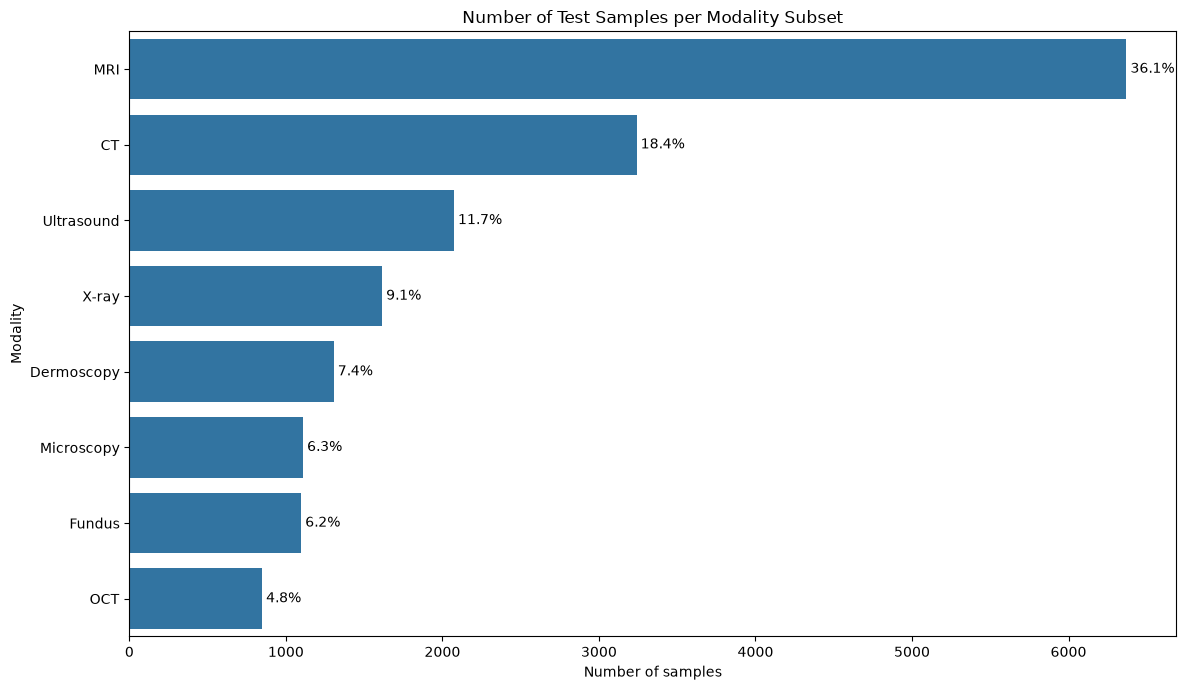

In [13]:
modality_subset_counts = (
    df_mod.groupby(["subset", "modality"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

modality_subset_counts["percent"] = modality_subset_counts["count"] / modality_subset_counts["count"].sum() * 100

display(modality_subset_counts)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=modality_subset_counts,
    x="count",
    y="modality"
)

for i, row in modality_subset_counts.iterrows():
    ax.text(
        row["count"],
        i,
        f' {row["percent"]:.1f}%',
        va="center"
    )

plt.title("Number of Test Samples per Modality Subset")
plt.xlabel("Number of samples")
plt.ylabel("Modality")
plt.tight_layout()
plt.show()

,subset,question_type,count,percent
0,qt-dd,Disease Diagnosis,11058,61.711033
1,qt-ai,Anatomy Identification,3329,18.578046
2,qt-mr,Modality Recognition,2392,13.348959
3,qt-oba,Other Biological Attributes,704,3.928791
4,qt-lg,Lesion Grading,436,2.433171


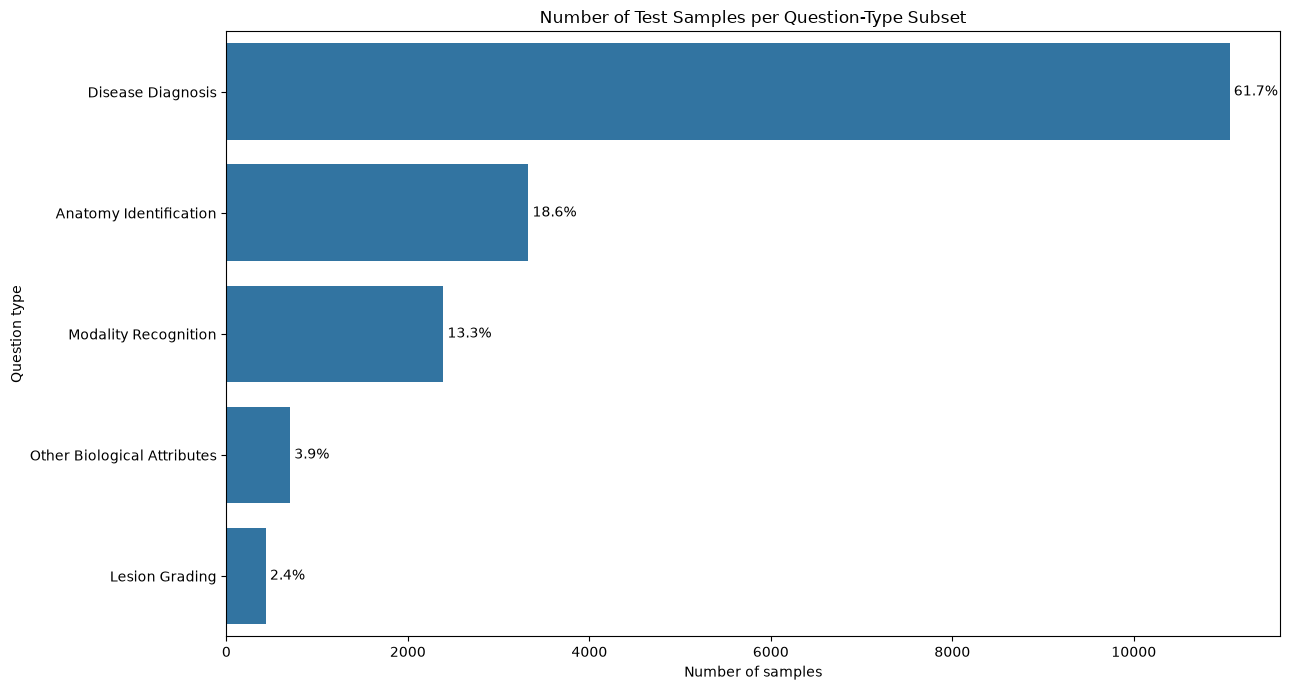

In [14]:
qt_subset_counts = (
    df_qt.groupby(["subset", "question_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

qt_subset_counts["percent"] = qt_subset_counts["count"] / qt_subset_counts["count"].sum() * 100

display(qt_subset_counts)

plt.figure(figsize=(13,7))

ax = sns.barplot(
    data=qt_subset_counts,
    x="count",
    y="question_type"
)


for i, row in qt_subset_counts.iterrows():
    ax.text(
        row["count"],
        i,
        f' {row["percent"]:.1f}%',
        va="center"
    )

plt.title("Number of Test Samples per Question-Type Subset")
plt.xlabel("Number of samples")
plt.ylabel("Question type")
plt.tight_layout()
plt.show()

# Answer Distribution

answer_letter
A    4803
B    4758
C    4080
D    4021
Name: count, dtype: int64

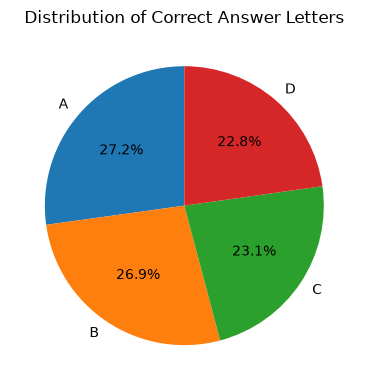

In [15]:
display(df_mod["answer_letter"].value_counts())

answer_counts = df_mod["answer_letter"].value_counts().reindex(["A", "B", "C", "D"])

plt.figure(figsize=(4, 4))

plt.pie(
    answer_counts,
    labels=answer_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Correct Answer Letters")
plt.tight_layout()
plt.show()

answer_letter
B    4894
A    4841
D    4123
C    4061
Name: count, dtype: int64

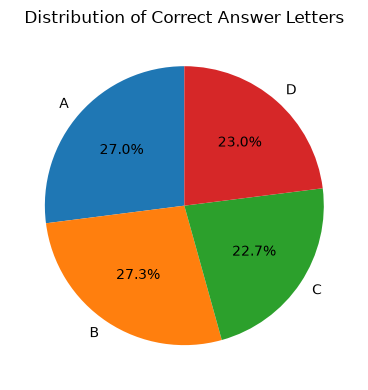

In [16]:
display(df_qt["answer_letter"].value_counts())

answer_counts = df_qt["answer_letter"].value_counts().reindex(["A", "B", "C", "D"])

plt.figure(figsize=(4, 4))

plt.pie(
    answer_counts,
    labels=answer_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Correct Answer Letters")
plt.tight_layout()
plt.show()

## Visualize random example

Example 1 | dataset index: 7296


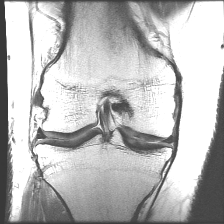

modality: MR (Magnetic Resonance Imaging)
image: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224 at 0x723288412FD0>
problem: Which type of imaging was employed for this image? A)MRI, B)X-ray, C)Angiography, D)Endoscopy
solution: <answer> A </answer>
question: Which type of imaging was employed for this image?
choice_a: MRI
choice_b: X-ray
choice_c: Angiography
choice_d: Endoscopy
answer_letter: A
answer_text: MRI
modality: MR (Magnetic Resonance Imaging)
question_type: Modality Recognition
subset: mod-mri
category: modality
Example 2 | dataset index: 1639


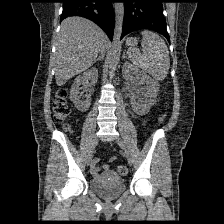

modality: CT(Computed Tomography)
image: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224 at 0x723288413ED0>
problem: What is the observation in this image indicating an abnormality? A)Blocked urinary tract, B)Contracted urinary tract, C)Dilated urinary tract, D)Inflamed urinary tract
solution: <answer> C </answer>
question: What is the observation in this image indicating an abnormality?
choice_a: Blocked urinary tract
choice_b: Contracted urinary tract
choice_c: Dilated urinary tract
choice_d: Inflamed urinary tract
answer_letter: C
answer_text: Dilated urinary tract
modality: CT(Computed Tomography)
question_type: Disease Diagnosis
subset: mod-ct
category: modality
Example 3 | dataset index: 18024


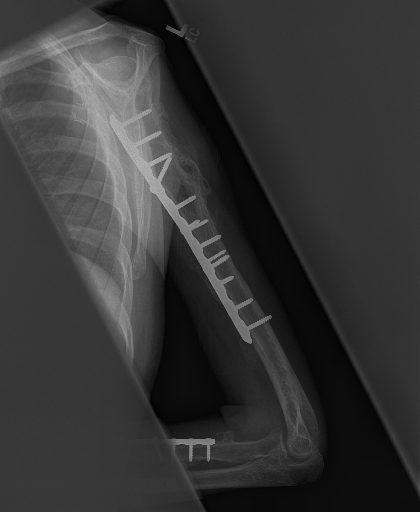

modality: X-Ray
image: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=420x512 at 0x723288413D90>
problem: What part of the anatomy is represented in this picture? A)Endocrine system, B)Nervous system, C)Musculoskeletal system, D)Respiratory system
solution: <answer> C </answer>
question: What part of the anatomy is represented in this picture?
choice_a: Endocrine system
choice_b: Nervous system
choice_c: Musculoskeletal system
choice_d: Respiratory system
answer_letter: C
answer_text: Musculoskeletal system
modality: X-Ray
question_type: Anatomy Identification
subset: qt-ai
category: question_type


In [17]:
def show_random_examples(dataset, n=3, seed=42):

    rng = random.Random(seed)
    sample_size = min(n, len(dataset))
    indices = rng.sample(range(len(dataset)), sample_size)

    fields_to_print = dataset.column_names

    for display_index, dataset_index in enumerate(indices, start=1):
        sample = dataset[dataset_index]
        print("=" * 100)
        print(f"Example {display_index} | dataset index: {dataset_index}")

        display(sample["image"])
        print(f"modality: {sample['modality']}")

        for field in fields_to_print:
            value = sample[field]
            print(f"{field}: {value}")

show_random_examples(test_ds, n=3, seed=42)

## One sample from each modality

The first modality-category sample is shown for each normalized modality.

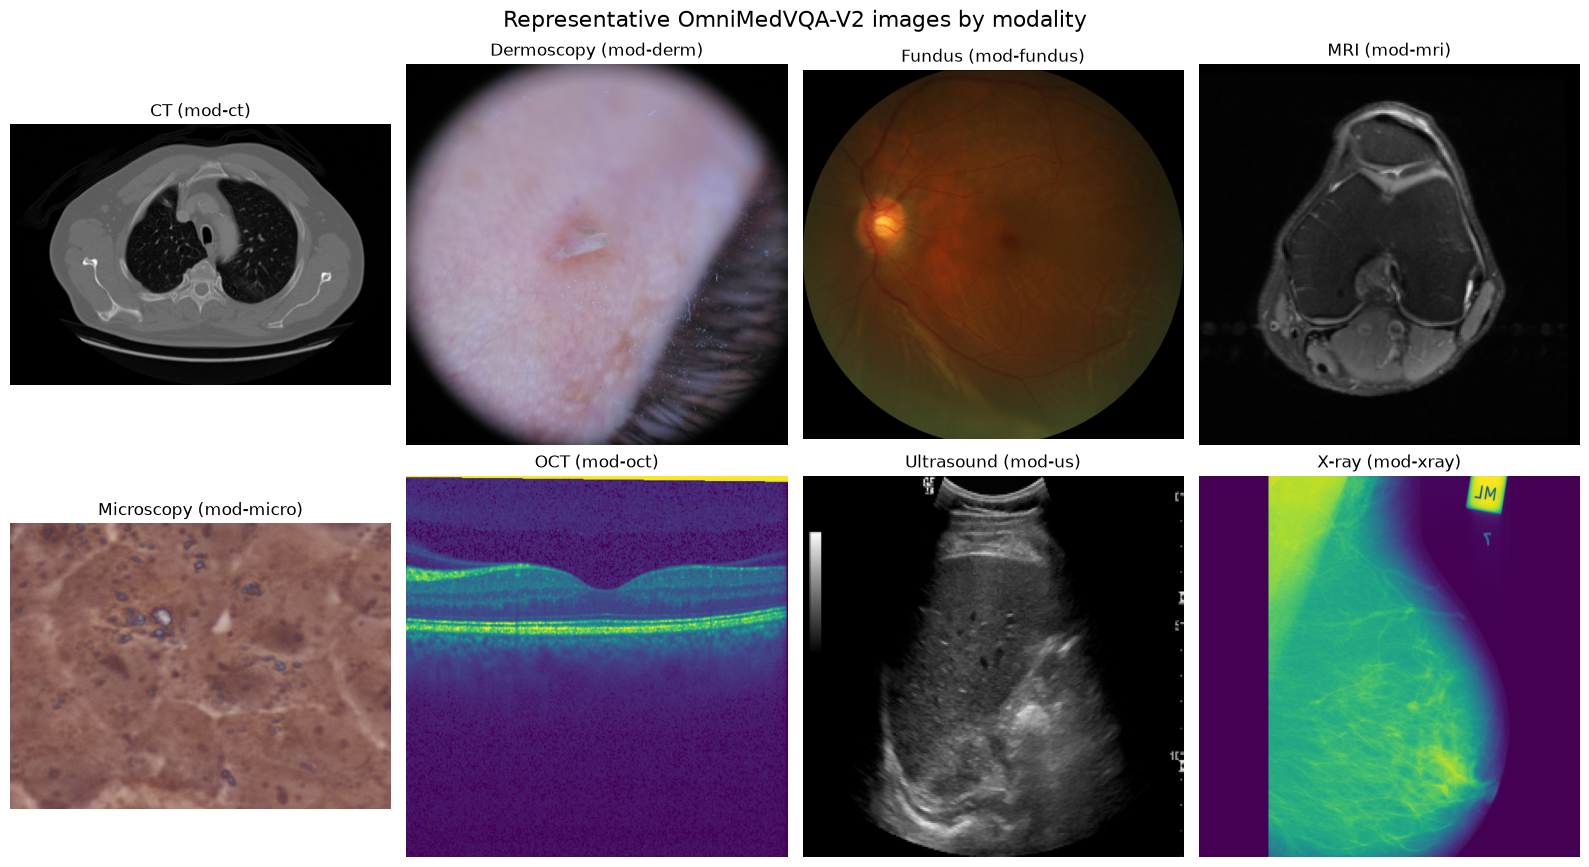

In [18]:
# Keep the image row aligned with the corresponding row in test_ds.
modality_samples = (
    df[df["category"] == "modality"]
    .assign(dataset_index=lambda frame: frame.index)
    .sort_values("dataset_index")
    .drop_duplicates("modality")
    .sort_values("modality")
)

n_samples = len(modality_samples)
n_cols = 4
n_rows = (n_samples + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, modality_samples.iterrows()):
    sample = test_ds[int(row["dataset_index"])]
    ax.imshow(sample["image"])
    ax.set_title(f"{row['modality']} ({row['subset']})", fontsize=12)
    ax.set_xlabel(
        f"Q: {sample['question']}\nAnswer: {sample['answer_text']}",
        fontsize=8,
    )
    ax.axis("off")

for ax in axes[n_samples:]:
    ax.axis("off")

fig.suptitle("Representative OmniMedVQA-V2 images by modality", fontsize=16)
plt.tight_layout()
plt.show()

## Summary


In [19]:
print(f"Total rows in test dataset: {len(test_ds):,}")
print(f"Total rows in modality category: {len(df_mod):,}")
print(f"Total rows in question-type category: {len(df_qt):,}")

display(modality_subset_counts)
display(qt_subset_counts)

Total rows in test dataset: 35,581
Total rows in modality category: 17,662
Total rows in question-type category: 17,919


,subset,modality,count,percent
0,mod-mri,MRI,6370,36.066131
1,mod-ct,CT,3241,18.350130
2,mod-us,Ultrasound,2074,11.742724
3,mod-xray,X-ray,1615,9.143925
4,mod-derm,Dermoscopy,1306,7.394406
5,mod-micro,Microscopy,1110,6.284679
6,mod-fundus,Fundus,1098,6.216736
7,mod-oct,OCT,848,4.801268


,subset,question_type,count,percent
0,qt-dd,Disease Diagnosis,11058,61.711033
1,qt-ai,Anatomy Identification,3329,18.578046
2,qt-mr,Modality Recognition,2392,13.348959
3,qt-oba,Other Biological Attributes,704,3.928791
4,qt-lg,Lesion Grading,436,2.433171
